# **Homework 2**

In [7]:
# Importazione delle librerie necessarie
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample


### **Caricamento del dataset CIFAR-10** 

In [8]:
# Caricamento del dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Etichette delle classi CIFAR-10
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# Appiattimento delle immagini e delle label
X_train_flatten = X_train.reshape(X_train.shape[0], -1)
X_test_flatten = X_test.reshape(X_test.shape[0], -1)

y_train_flatten = y_train.flatten()
y_test_flatten = y_test.flatten()

# Normalizzazione delle immagini
X_train_normalized = X_train_flatten.astype('float32') / 255.0
X_test_normalized = X_test_flatten.astype('float32') / 255.0

print(f"Training set dopo appiattimento and normalizzazione: {X_train_normalized.shape}, Test set: {X_test_normalized.shape}")

# Sotto-campionamento
X_train_sub, y_train_sub = resample(
    X_train_normalized, y_train_flatten,
    replace=False,
    n_samples=5000, 
    random_state=42,
    stratify=y_train_flatten
)

print(f"Training set dopo sotto-campionamento: {X_train_sub.shape}")



Training set: (50000, 32, 32, 3), Test set: (10000, 32, 32, 3)
Training set dopo appiattimento and normalizzazione: (50000, 3072), Test set: (10000, 3072)
Training set dopo sotto-campionamento: (5000, 3072)


### **Standardizzazione del dataset e PCA**

Varianza spiegata: 0.9001
Numero di componenti dopo PCA: 97
Forma dei dati dopo PCA: (5000, 97)


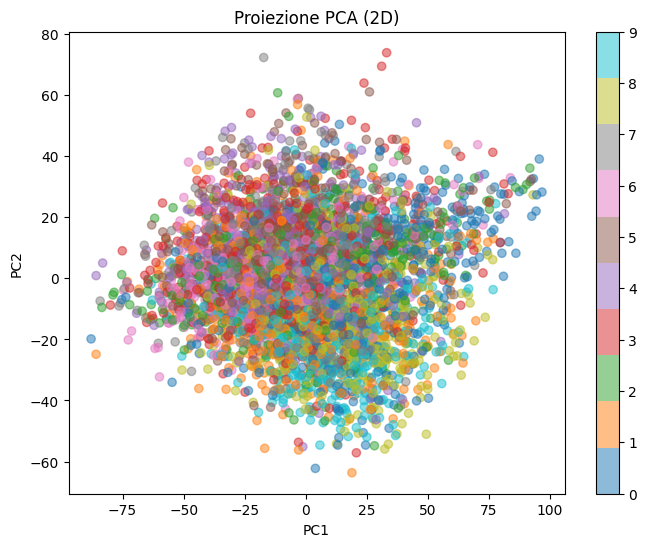

In [9]:
# Standardizzazione dei dati
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_test_scaled = scaler.transform(X_test_normalized)

# Applicazione della PCA per ridurre la dimensionalità
pca = PCA(n_components=97)  
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Verifica della varianza
print(f"Varianza spiegata: {sum(pca.explained_variance_ratio_):.4f}")
print(f"Numero di componenti dopo PCA: {pca.n_components_}")
print(f"Forma dei dati dopo PCA: {X_train_pca.shape}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_sub, cmap='tab10', alpha=0.5)
plt.title("Proiezione PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter)
plt.show()

### **Addestramento e valutazione dei modelli** 

In [ ]:
# Dizionario dei modelli
models = {
    "K-NN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Griglie dei parametri per ciascun modello
param_grids = {
    "K-NN": {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'kd_tree']
    },
    "Logistic Regression": {
        'C': [0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'max_iter': [1000]
    },
    "SVM": {  
        'C': [0.1, 1, 10],  
        'kernel': ['linear', 'rbf'],  
        'gamma': ['scale', 'auto'],
        'max_iter': [1000]
    },
    "Decision Tree": {
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'criterion': ['gini', 'entropy']
    }
}

# Funzione per eseguire Grid Search e valutazione
def evaluate_model(model_name, model, param_grid, X_train, y_train, X_test, y_test):
    print(f"\nGrid search per: {model_name}")
    
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train.ravel())
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Migliori parametri per {model_name}: {grid_search.best_params_}")
    print(f"Accuracy sul test set: {accuracy:.4f}")

    print("\nReport di Classificazione:")
    print(classification_report(y_test, y_pred, target_names=label_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Matrice di Confusione - {model_name}")
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return best_model, accuracy

# Valutazione di tutti i modelli
best_models = {}
accuracies = {}

for model_name, model in models.items():
    best_model, accuracy = evaluate_model(
        model_name, model, param_grids[model_name],
         X_train_pca, y_train_sub, X_test_pca, y_test
    )
    best_models[model_name] = best_model
    accuracies[model_name] = accuracy

best_model_name = max(accuracies, key=accuracies.get)
print(f"\nIl miglior modello è: {best_model_name} con accuracy = {accuracies[best_model_name]:.4f}")


Grid search per: K-NN
